In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
engine = create_engine('mssql+pyodbc://localhost\\SQLEXPRESS/HealthInsuranceDB?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes')
df = pd.read_sql('SELECT * FROM insurance', engine)
print("Shape:", df.shape)
print(df.head())
print(df.describe().T)
print(df.info())
print(df.isnull().sum())

Shape: (1338, 7)
   age     sex    bmi  children smoker     region   charges
0   19  female  27.90         0    yes  southwest  16884.92
1   18    male  33.77         1     no  southeast   1725.55
2   28    male  33.00         3     no  southeast   4449.46
3   33    male  22.71         0     no  northwest  21984.47
4   32    male  28.88         0     no  northwest   3866.86
           count          mean           std      min        25%      50%  \
age       1338.0     39.207025     14.049960    18.00    27.0000    39.00   
bmi       1338.0     30.664581      6.097922    15.96    26.2975    30.40   
children  1338.0      1.094918      1.205493     0.00     0.0000     1.00   
charges   1338.0  13270.422414  12110.011240  1121.87  4740.2875  9382.03   

                75%       max  
age          51.000     64.00  
bmi          34.695     53.13  
children      2.000      5.00  
charges   16639.915  63770.43  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Dat

C:\Users\USER\anaconda3\Lib\site-packages\pandas\io\sql.py:1636: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [3]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicates before: 1
Duplicates after: 0
New shape: (1337, 7)


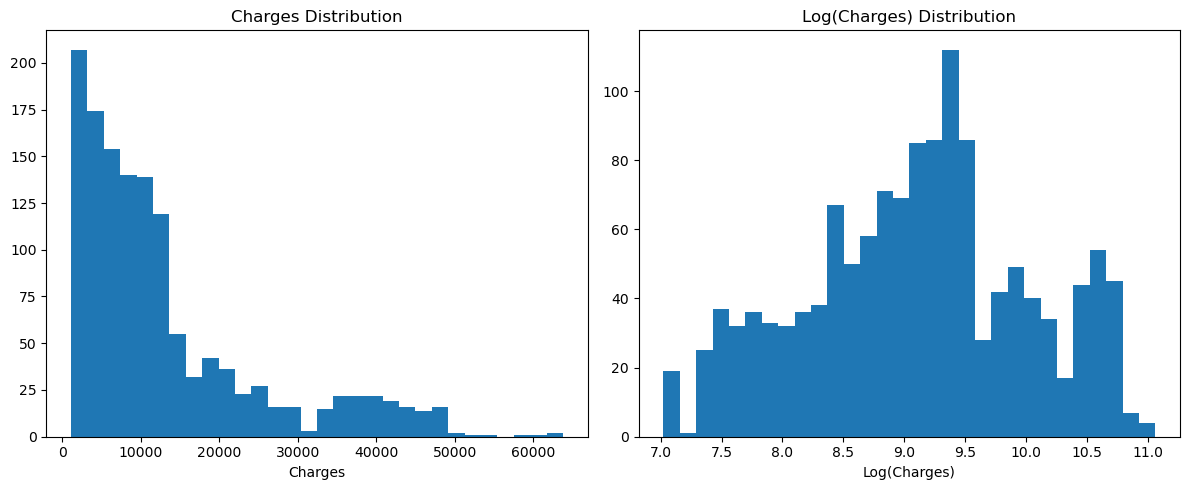

Skewness: 1.52


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['charges'], bins=30)
axes[0].set_title('Charges Distribution')
axes[0].set_xlabel('Charges')
axes[1].hist(np.log(df['charges']), bins=30)
axes[1].set_title('Log(Charges) Distribution')
axes[1].set_xlabel('Log(Charges)')
plt.tight_layout()
plt.show()

print("Skewness:", round(df['charges'].skew(), 2))

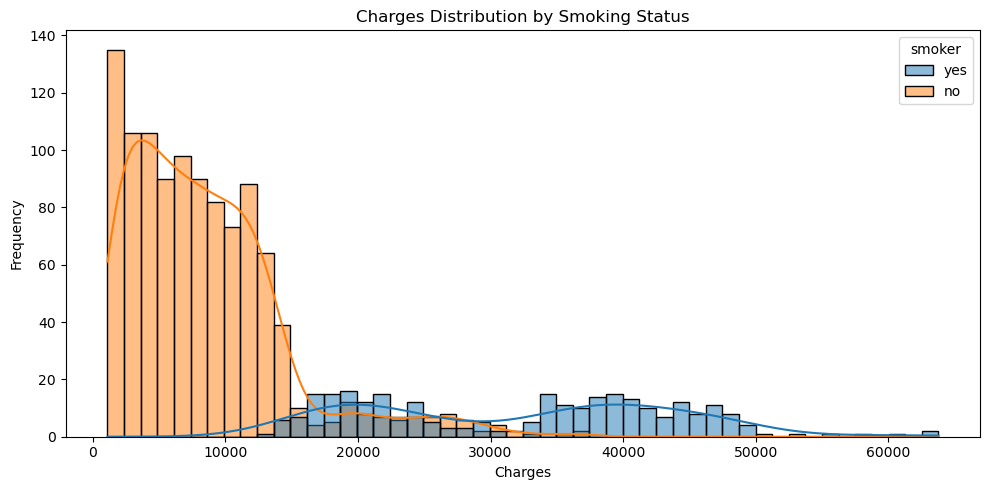

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='charges', hue='smoker', bins=50, kde=True)
plt.title('Charges Distribution by Smoking Status')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

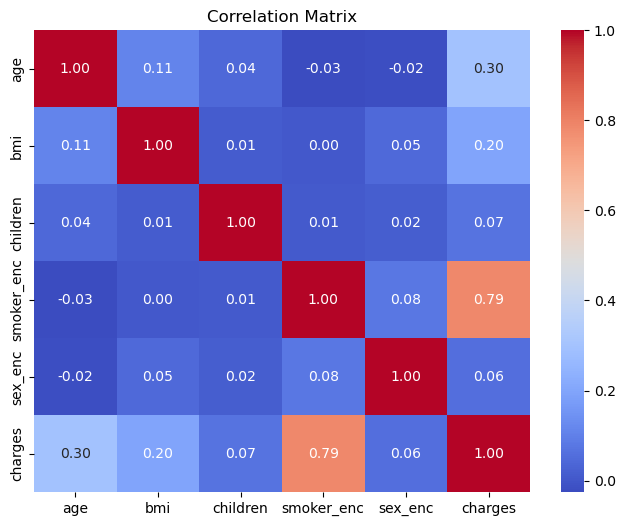

In [6]:
df_corr = df.copy()
df_corr['smoker_enc'] = (df_corr['smoker'] == 'yes').astype(int)
df_corr['sex_enc'] = (df_corr['sex'] == 'male').astype(int)

corr = df_corr[['age', 'bmi', 'children', 'smoker_enc', 'sex_enc', 'charges']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

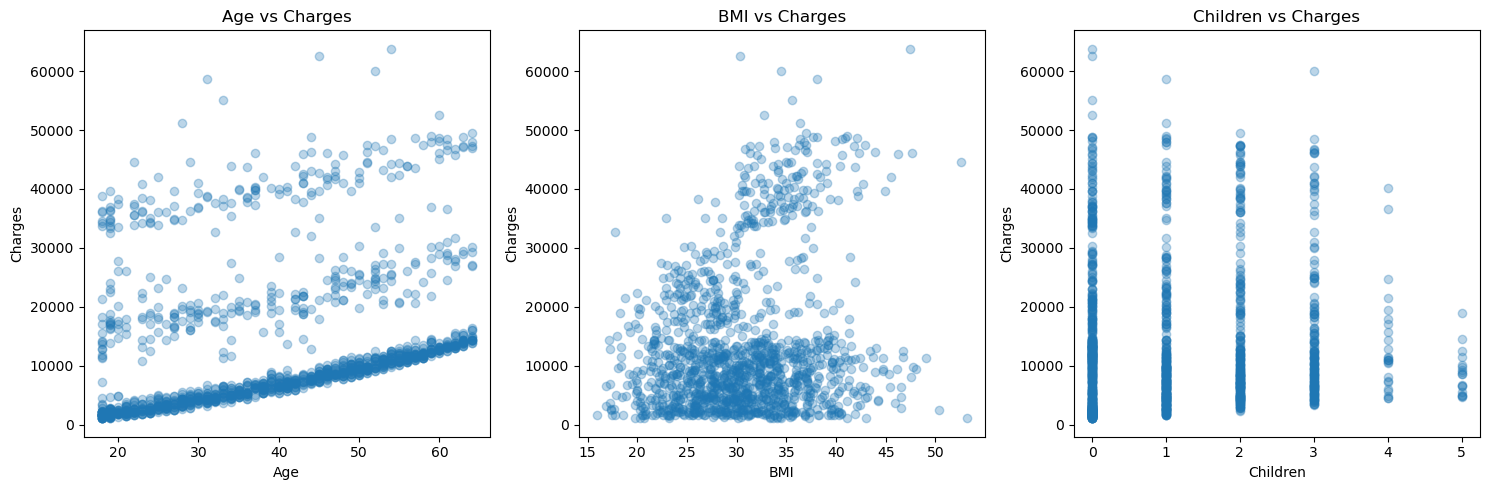

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(df['age'], df['charges'], alpha=0.3)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges')
axes[0].set_title('Age vs Charges')
axes[1].scatter(df['bmi'], df['charges'], alpha=0.3)
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges')
axes[1].set_title('BMI vs Charges')
axes[2].scatter(df['children'], df['charges'], alpha=0.3)
axes[2].set_xlabel('Children')
axes[2].set_ylabel('Charges')
axes[2].set_title('Children vs Charges')
plt.tight_layout()
plt.show()

In [8]:
df_model = df.copy()

# Binary encoding
df_model['smoker'] = (df_model['smoker'] == 'yes').astype(int)
df_model['sex'] = (df_model['sex'] == 'male').astype(int)

# One-hot encoding (drop_first=True)
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True, dtype=int)

# Log transformation
df_model['log_charges'] = np.log(df_model['charges'])

# Interaction terms
df_model['smoker_bmi'] = df_model['smoker'] * df_model['bmi']
df_model['smoker_age'] = df_model['smoker'] * df_model['age']

print(df_model.head())
print(df_model.columns.tolist())

   age  sex    bmi  children  smoker   charges  region_northwest  \
0   19    0  27.90         0       1  16884.92                 0   
1   18    1  33.77         1       0   1725.55                 0   
2   28    1  33.00         3       0   4449.46                 0   
3   33    1  22.71         0       0  21984.47                 1   
4   32    1  28.88         0       0   3866.86                 1   

   region_southeast  region_southwest  log_charges  smoker_bmi  smoker_age  
0                 0                 1     9.734176        27.9          19  
1                 1                 0     7.453301         0.0           0  
2                 1                 0     8.400538         0.0           0  
3                 0                 0     9.998092         0.0           0  
4                 0                 0     8.260198         0.0           0  
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'log_charges',

In [9]:
X = df_model[['age', 'sex', 'bmi', 'children', 'smoker',
              'region_northwest', 'region_southeast', 'region_southwest',
              'smoker_bmi', 'smoker_age']]
y = df_model['log_charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1069, 10)
Test size: (268, 10)


In [10]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
print("R² Score :", round(r2, 4))

R² Score : 0.8709


In [11]:
feature_names = ['age', 'sex', 'bmi', 'children', 'smoker',
                 'region_northwest', 'region_southeast', 'region_southwest',
                 'smoker_bmi', 'smoker_age']

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients.to_string(index=False))

coefficients['% Effect'] = (np.exp(coefficients['Coefficient']) - 1) * 100
print("\n=== % Effect on Charges ===")
print(coefficients[['Feature', '% Effect']].sort_values('% Effect', ascending=False).to_string(index=False))

         Feature  Coefficient
      smoker_bmi     0.670789
             age     0.577750
          smoker     0.481668
        children     0.130303
             bmi     0.001375
region_northwest    -0.015354
             sex    -0.043140
region_southeast    -0.049062
region_southwest    -0.054072
      smoker_age    -0.560858

=== % Effect on Charges ===
         Feature   % Effect
      smoker_bmi  95.578032
             age  78.202396
          smoker  61.877223
        children  13.917349
             bmi   0.137593
region_northwest  -1.523648
             sex  -4.222241
region_southeast  -4.787775
region_southwest  -5.263628
      smoker_age -42.928092


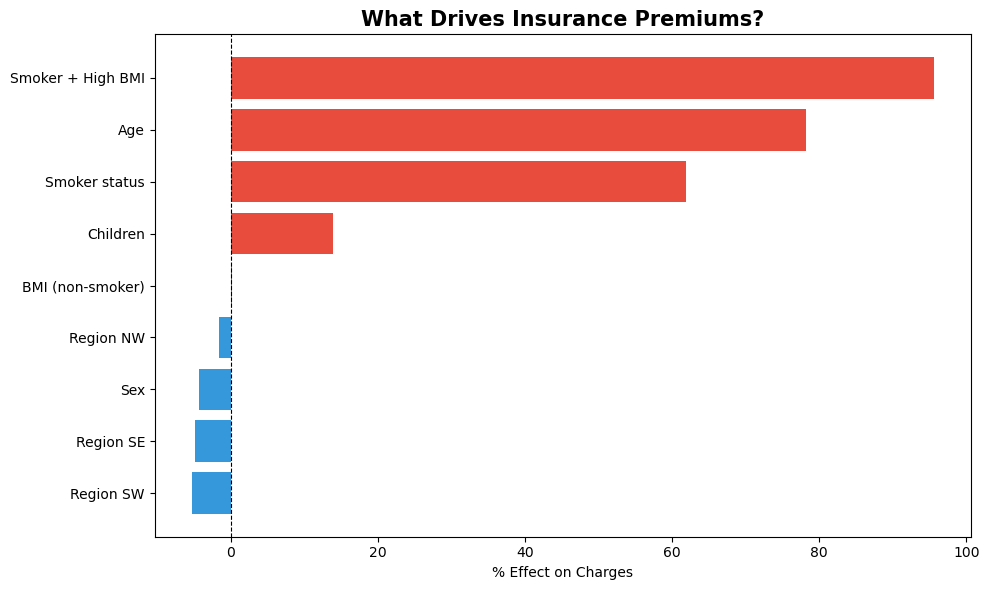

In [13]:
label_map = {
    'smoker_bmi'       : 'Smoker + High BMI',
    'smoker'           : 'Smoker status',
    'age'              : 'Age',
    'children'         : 'Children',
    'bmi'              : 'BMI (non-smoker)',
    'region_northwest' : 'Region NW',
    'region_southeast' : 'Region SE',
    'region_southwest' : 'Region SW',
    'sex'              : 'Sex'
}

# smoker_age interaction'ı grafikten çıkar
plot_features = ['smoker_bmi', 'smoker', 'age', 'children', 'bmi',
                 'region_northwest', 'region_southeast', 'region_southwest', 'sex']

coefficients['Factor'] = coefficients['Feature'].map(label_map)

real_effects = (
    coefficients[coefficients['Feature'].isin(plot_features)][['Factor', '% Effect']]
    .sort_values('% Effect')
)
bar_colors = ['#e74c3c' if x > 0 else '#3498db' for x in real_effects['% Effect']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(real_effects['Factor'], real_effects['% Effect'], color=bar_colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('What Drives Insurance Premiums?', fontsize=15, fontweight='bold')
ax.set_xlabel('% Effect on Charges')
plt.tight_layout()
plt.show()

In [14]:
# Predict on entire dataset
X_all = df_model[['age', 'sex', 'bmi', 'children', 'smoker',
                   'region_northwest', 'region_southeast', 'region_southwest',
                   'smoker_bmi', 'smoker_age']].copy()

X_all_scaled = scaler.transform(X_all)

# Convert predictions back to real scale (inverse log)
df_predictions = df.copy()
df_predictions['predicted_charges'] = np.exp(model.predict(X_all_scaled))
df_predictions['actual_charges'] = df['charges']

# Risk group — consistent with SQL (vw_risk_segmentation)
# smoker=yes → High Risk | bmi>=30 → Medium Risk | otherwise → Low Risk
def assign_risk(row):
    if row['smoker'] == 'yes':
        return 'High Risk'
    elif row['bmi'] >= 30:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_predictions['risk_group'] = df.apply(assign_risk, axis=1)

# Save to SQL Server
df_predictions.to_sql('insurance_predictions', engine, if_exists='replace', index=False)

print("Predictions saved to SQL Server!")
print(df_predictions.head())
print("\nRisk Group Distribution:")
print(df_predictions['risk_group'].value_counts())

Predictions saved to SQL Server!
   age     sex    bmi  children smoker     region   charges  \
0   19  female  27.90         0    yes  southwest  16884.92   
1   18    male  33.77         1     no  southeast   1725.55   
2   28    male  33.00         3     no  southeast   4449.46   
3   33    male  22.71         0     no  northwest  21984.47   
4   32    male  28.88         0     no  northwest   3866.86   

   predicted_charges  actual_charges   risk_group  
0       19565.300673        16884.92    High Risk  
1        2480.281528         1725.55  Medium Risk  
2        4661.527208         4449.46  Medium Risk  
3        4442.490200        21984.47     Low Risk  
4        4268.772456         3866.86     Low Risk  

Risk Group Distribution:
risk_group
Medium Risk    561
Low Risk       502
High Risk      274
Name: count, dtype: int64


## Key Findings

- The strongest driver of insurance charges is the **interaction between smoking and high BMI** (~95% increase).
- **Age** is the second most influential factor (~78% increase per standard deviation).
- **BMI alone** has almost no effect on premiums — its impact only emerges in combination with smoking.
- **Region and sex** have minimal and slightly negative effects, suggesting near-equal pricing across demographics.